# **import library**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# **Manage Dataset**

In [2]:
# โหลด MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize & reshape
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

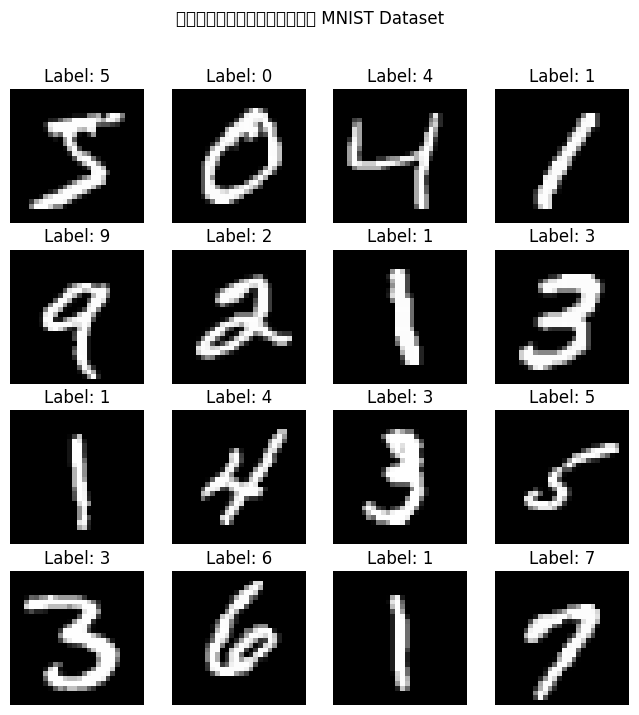

In [3]:
# =========================
# 1. แสดงตัวอย่างภาพ MNIST
# =========================
plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("ตัวอย่างภาพจาก MNIST Dataset")
plt.show()

In [4]:
# =========================
# 2. แสดงข้อมูล DataFrame
# =========================
df = pd.DataFrame({
    "Index": np.arange(len(y_train)),
    "Label": y_train
})
print("\nตัวอย่าง DataFrame:")
print(df.head())



ตัวอย่าง DataFrame:
   Index  Label
0      0      5
1      1      0
2      2      4
3      3      1
4      4      9


# **สร้าง CNN model** และ Train ข้อมูล

In [5]:
# สร้าง CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Train
history = model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9502 - loss: 0.1690 - val_accuracy: 0.9787 - val_loss: 0.0643
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9827 - loss: 0.0583 - val_accuracy: 0.9806 - val_loss: 0.0573
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9879 - loss: 0.0396 - val_accuracy: 0.9844 - val_loss: 0.0450


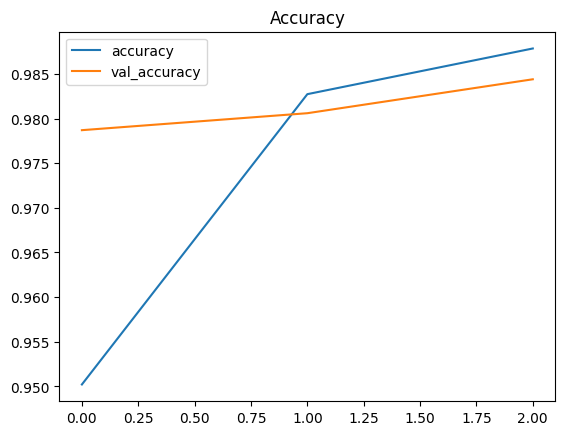

In [7]:
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

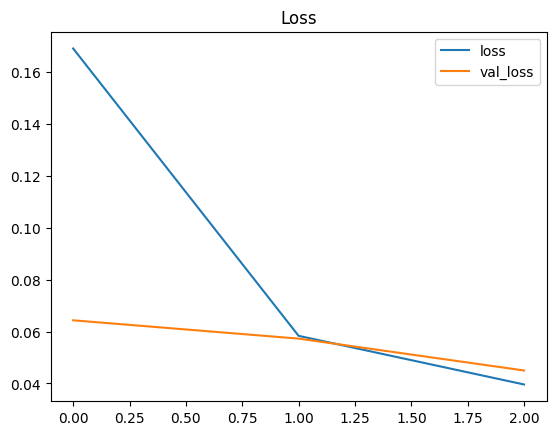

In [8]:
pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.title("Loss")
plt.show()

# **Analysis**

In [9]:
# =========================
# 5. Evaluation
# =========================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc*100:.2f} %, Test loss: {test_loss*100:.2f} %")

313/313 - 1s - 2ms/step - accuracy: 0.9844 - loss: 0.0450

Test accuracy: 98.44 %, Test loss: 4.50 %


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


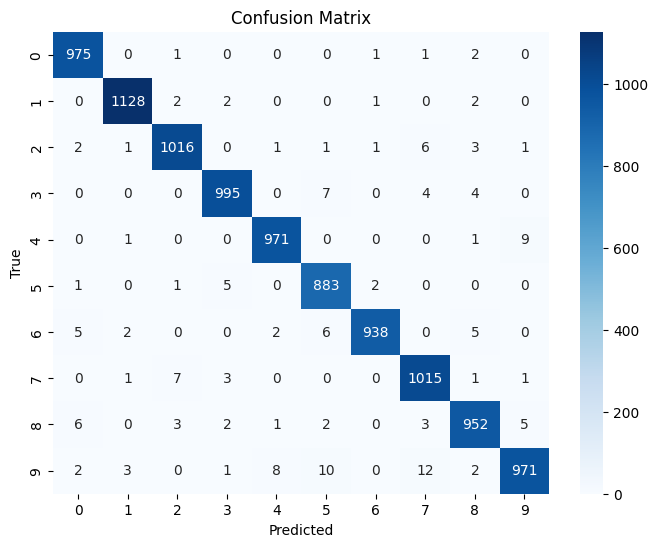

In [10]:
# =========================
# 6. Confusion Matrix
# =========================
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [11]:
# =========================
# 7. Classification Report
# =========================
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9839    0.9949    0.9893       980
           1     0.9930    0.9938    0.9934      1135
           2     0.9864    0.9845    0.9855      1032
           3     0.9871    0.9851    0.9861      1010
           4     0.9878    0.9888    0.9883       982
           5     0.9714    0.9899    0.9806       892
           6     0.9947    0.9791    0.9868       958
           7     0.9750    0.9874    0.9812      1028
           8     0.9794    0.9774    0.9784       974
           9     0.9838    0.9623    0.9729      1009

    accuracy                         0.9844     10000
   macro avg     0.9842    0.9843    0.9843     10000
weighted avg     0.9844    0.9844    0.9844     10000



# **บันทึกโมเดลไปใช้**

In [12]:
# บันทึกโมเดลทั้งก้อน
model.save("mnist_cnn_model.h5")

## **เรียกใช้งานโมเดล**

In [13]:
# โหลดกลับมาใช้งาน
from tensorflow.keras.models import load_model
loaded_model = load_model("mnist_cnn_model.h5")

# ใช้งานเหมือนเดิม
loss, acc = loaded_model.evaluate(x_test, y_test)
print(f"Loaded model accuracy: {acc*100:.4f} %")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9844 - loss: 0.0450
Loaded model accuracy: 98.4400 %


In [14]:
import cv2

In [15]:
def preprocess_image(img_path, target_size=(28,28)):
    # 1. โหลดภาพ
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # แปลงเป็น grayscale

    # 2. Resize ให้ตรงกับโมเดล
    img_resized = cv2.resize(img, target_size)

    # 3. Normalize (0-255 → 0-1)
    img_normalized = img_resized / 255.0

    # 4. เพิ่ม dimension สำหรับ batch และ channel
    img_array = img_normalized.reshape(1, target_size[1], target_size[0], 1)

    return img_array

In [17]:
X = preprocess_image(r"/content/images.jpeg", target_size=(28,28))

# predict
output = loaded_model.predict(X)
predicted_class = np.argmax(output)
print(output) # probabilities ของแต่ละ class
print(predicted_class) # index ของค่าที่เยอที่สุด

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
[[6.3857692e-03 1.3600177e-06 3.1298004e-02 1.8072456e-01 3.8850189e-06
  3.6206041e-03 1.9186058e-03 5.9571881e-05 7.7449226e-01 1.4953100e-03]]
8


# **Tensorflow => Tensorflowjs**

In [18]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting un

In [19]:
!tensorflowjs_converter --input_format=keras /content/mnist_cnn_model.h5 mnist_cnn_tfjs_model/

2026-06-25 08:26:12.267315: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782375972.288800    3608 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782375972.295800    3608 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782375972.313373    3608 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782375972.313415    3608 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782375972.313419    3608 computation_placer.cc:177] computation placer alr

In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
import tensorflowjs as tfjs
print(tfjs.__version__)